In [ ]:
dataset : https://drive.google.com/file/d/1WS9bWjqJw1aid5euZyfF7BW_rul8Zjvv/view

In [2]:
# Importing the standard libraries

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("vgsales.csv")

In [5]:
# no of rows and columns in a dataset
df.shape

(16598, 11)

In [6]:
# print names of all the columns
df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

In [ ]:
--> This dataset has been collected from vgchartz.com and combined into one dataset.
--> This data was automatically collected from many places/websites using web scraping techniques.
    And all collected data was organized into one table or data set.
--> This dataset is probably about video games,including details like:
    * game name
    * platform
    * genre 
    * publisher
    * sales
    * release year, etc.
--> In data analysis project this description tells us "where the data came from and how it was collected".

In [8]:
# print sample 10 rows from data
df.sample(10, random_state = 5)
# here, the number (5) usually doesn't have a special meaning. it just acts like a SEED to control randomness.
# and here, random_state is used to get the same output everytime you run the code.

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
9330,9332,Legendary,PS3,2008.0,Shooter,Atari,0.08,0.03,0.00,0.02,0.13
5851,5853,Shrek: Forever After,Wii,2010.0,Platform,Activision,0.19,0.09,0.00,0.03,0.30
9957,9959,Deadpool,XOne,2015.0,Action,Activision,0.08,0.03,0.00,0.01,0.12
15550,15553,Motto NUGA-CEL!,PSP,2010.0,Adventure,Idea Factory,0.00,0.00,0.02,0.00,0.02
6522,6524,Nightmare Creatures,N64,1996.0,Action,Activision,0.21,0.05,0.00,0.00,0.26
6170,6172,MX SuperFly featuring Ricky Carmichael,PS2,2002.0,Racing,THQ,0.14,0.11,0.00,0.04,0.28
15436,15439,Painkiller: Hell & Damnation,X360,2013.0,Shooter,Nordic Games,0.00,0.01,0.00,0.00,0.02
3873,3875,NFL 2K3,XB,2002.0,Sports,Sega,0.38,0.11,0.00,0.02,0.52
13893,13895,WRC: FIA World Rally Championship,PSP,2005.0,Racing,Sony Computer Entertainment,0.02,0.01,0.00,0.01,0.04
3771,3773,Mystery Dungeon: Shiren the Wanderer,DS,2006.0,Role-Playing,Sega,0.18,0.00,0.33,0.02,0.53


In [9]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
--> The meaning of each column in the dataset.
    This is called a data dictionary or column description.
--> Here's the meaning in simple words:

1. Rank           Position of the game based on global sales
2. Name           Name/title of the video game
3. Platform       Gaming console used to play the game
4. Year           Release year of the game
5. Genre          Type/category of game. (action,sports,racing,etc.)
6. Publisher      Company that published the game
7. NA_Sales       Sales in North America
8. EU_Sales       Sales in Europe
9. JP_Sales       Sales in Japan
10. Other_Sales   Sales in remaining countries
11. Global_Sales  Total worldwide sales

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [11]:
# Check for duplicate values
df.duplicated().sum()

np.int64(0)

In [12]:
# Check for null values
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [15]:
# Checks each row in the year column
# TRUE -> Year is MISSING
# FALSE -> Year exists
df["Year"].isna()

0        False
1        False
2        False
3        False
4        False
         ...  
16593    False
16594    False
16595    False
16596    False
16597    False
Name: Year, Length: 16598, dtype: bool

In [14]:
# it returns only the rows where the year column has missing values.
df[df["Year"].isna()]

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
...,...,...,...,...,...,...,...,...,...,...,...
16307,16310,Freaky Flyers,GC,NaN,Racing,Unknown,0.01,0.00,0.00,0.00,0.01
16327,16330,Inversion,PC,NaN,Shooter,Namco Bandai Games,0.01,0.00,0.00,0.00,0.01
16366,16369,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,Unknown,0.01,0.00,0.00,0.00,0.01
16427,16430,Virtua Quest,GC,NaN,Role-Playing,Unknown,0.01,0.00,0.00,0.00,0.01


In [16]:
# fill the null values with 0 which indicates that the value is actually missing
# year . it is integer col so we can fill with 0
df["Year"] = df["Year"].fillna(0)

In [17]:
df.isnull().sum()

Rank             0
Name             0
Platform         0
Year             0
Genre            0
Publisher       58
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64

In [18]:
df["Publisher"] = df["Publisher"].fillna("Unknown")
# There were already some Values with Unknown publisher
# so to maintain the consistency we have replaced the rest of null values
# as well with Unknown . because the publisher column is a object type column.

In [19]:
df.isnull().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16598 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16598 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [ ]:
Different ways to change data types in pandas
_____________________________________________

1. astype() --> Used to convert a column from one data type to another data type.
                we just need to be sure that the values inside the column are convertible. else it will raise an error
2. pd.to_numeric() --> used specifically to convert values into numeric data type ( int or float)
                       if the values present inside the column are int then the the col will be converted into int else float.

In [ ]:
--> " " --> can't be directly converted into integer
--> to_numeric is having a parameter known as errors = 'coerce' which can handle such noise string Values
--> it will convert them to NAN values

In [21]:
df["Year"] = df["Year"].astype(int)

In [22]:
df['Year']

0        2006
1        1985
2        2008
3        2009
4        1996
         ... 
16593    2002
16594    2003
16595    2008
16596    2010
16597    2003
Name: Year, Length: 16598, dtype: int64

In [23]:
df['Year'].value_counts()

Year
2009    1431
2008    1428
2010    1259
2007    1202
2011    1139
2006    1008
2005     941
2002     829
2003     775
2004     763
2012     657
2015     614
2014     582
2013     546
2001     482
1998     379
2000     349
2016     344
1999     338
1997     289
0        271
1996     263
1995     219
1994     121
1993      60
1981      46
1992      43
1991      41
1982      36
1986      21
1989      17
1983      17
1990      16
1987      16
1988      15
1985      14
1984      14
1980       9
2017       3
2020       1
Name: count, dtype: int64

In [ ]:
# Check if for 2020 is the data not collected properly or actually there were less releases.

In [ ]:
# dropna --> drop NaN
# df.drop(index, inplace = True)
# inplace = True means to make the changes in original dataset.

In [24]:
index_to_drop = df[df['Year'] == 2020].index
print(index_to_drop)

Index([5957], dtype='int64')


In [28]:
df.drop(index_to_drop, inplace = True)

In [29]:
df['Year'].value_counts()

Year
2009    1431
2008    1428
2010    1259
2007    1202
2011    1139
2006    1008
2005     941
2002     829
2003     775
2004     763
2012     657
2015     614
2014     582
2013     546
2001     482
1998     379
2000     349
2016     344
1999     338
1997     289
0        271
1996     263
1995     219
1994     121
1993      60
1981      46
1992      43
1991      41
1982      36
1986      21
1989      17
1983      17
1990      16
1987      16
1988      15
1985      14
1984      14
1980       9
2017       3
Name: count, dtype: int64

In [30]:
df['Year']

0        2006
1        1985
2        2008
3        2009
4        1996
         ... 
16593    2002
16594    2003
16595    2008
16596    2010
16597    2003
Name: Year, Length: 16597, dtype: int64

In [31]:
# This returns all rows where the YEAR value is != 0. i.e, Rows having year = 0 are removed. Remaining rows are shown
df[df['Year'] != 0]

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [33]:
# This does 2 things. filter rows where year != 0.and select only the year column.
df[df['Year'] != 0]['Year']

0        2006
1        1985
2        2008
3        2009
4        1996
         ... 
16593    2002
16594    2003
16595    2008
16596    2010
16597    2003
Name: Year, Length: 16326, dtype: int64

In [34]:
# find the minimum year value
df[df['Year'] != 0]['Year'].min()

1980

In [ ]:
--> we have got the data from 1980 to 2017

In [35]:
# How many unique platforms and publishers we are having?
df['Platform'].nunique()

31

In [36]:
df['Publisher'].nunique()

578

In [37]:
# Which platform and publisher had the earliest and the latest release as per our data?
earliest = df[df['Year'] == 1980]
print(earliest)

      Rank             Name Platform  Year     Genre   Publisher  NA_Sales  \
258    259        Asteroids     2600  1980   Shooter       Atari      4.00   
544    545  Missile Command     2600  1980   Shooter       Atari      2.56   
1766  1768          Kaboom!     2600  1980      Misc  Activision      1.07   
1969  1971         Defender     2600  1980      Misc       Atari      0.99   
2669  2671           Boxing     2600  1980  Fighting  Activision      0.72   
4025  4027       Ice Hockey     2600  1980    Sports  Activision      0.46   
5366  5368          Freeway     2600  1980    Action  Activision      0.32   
6317  6319           Bridge     2600  1980      Misc  Activision      0.25   
6896  6898         Checkers     2600  1980      Misc       Atari      0.22   

      EU_Sales  JP_Sales  Other_Sales  Global_Sales  
258       0.26       0.0         0.05          4.31  
544       0.17       0.0         0.03          2.76  
1766      0.07       0.0         0.01          1.15  
196

In [38]:
earliest['Platform'].nunique()

1

In [39]:
earliest['Platform'].unique()

array(['2600'], dtype=object)

In [40]:
earliest['Publisher'].nunique()

2

In [41]:
earliest['Publisher'].unique()

array(['Atari', 'Activision'], dtype=object)

In [43]:
latest = df[df['Year'] == 2017]
print(latest)

        Rank                                              Name Platform  Year  \
14390  14393  Phantasy Star Online 2 Episode 4: Deluxe Package      PS4  2017   
16241  16244  Phantasy Star Online 2 Episode 4: Deluxe Package      PSV  2017   
16438  16441                  Brothers Conflict: Precious Baby      PSV  2017   

              Genre     Publisher  NA_Sales  EU_Sales  JP_Sales  Other_Sales  \
14390  Role-Playing          Sega       0.0       0.0      0.03          0.0   
16241  Role-Playing          Sega       0.0       0.0      0.01          0.0   
16438        Action  Idea Factory       0.0       0.0      0.01          0.0   

       Global_Sales  
14390          0.03  
16241          0.01  
16438          0.01  


In [44]:
# Which is the platform with most game releases?
df['Platform'].value_counts().idxmax()

'DS'

In [45]:
# Which publisher has made the most games?
df['Publisher'].value_counts().idxmax()

'Electronic Arts'

In [47]:
# Which are the top 10 best-selling games globally?
top_games = df.sort_values("Global_Sales", ascending = False).head(10)
print(top_games)

   Rank                       Name Platform  Year         Genre Publisher  \
0     1                 Wii Sports      Wii  2006        Sports  Nintendo   
1     2          Super Mario Bros.      NES  1985      Platform  Nintendo   
2     3             Mario Kart Wii      Wii  2008        Racing  Nintendo   
3     4          Wii Sports Resort      Wii  2009        Sports  Nintendo   
4     5   Pokemon Red/Pokemon Blue       GB  1996  Role-Playing  Nintendo   
5     6                     Tetris       GB  1989        Puzzle  Nintendo   
6     7      New Super Mario Bros.       DS  2006      Platform  Nintendo   
7     8                   Wii Play      Wii  2006          Misc  Nintendo   
8     9  New Super Mario Bros. Wii      Wii  2009      Platform  Nintendo   
9    10                  Duck Hunt      NES  1984       Shooter  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.8

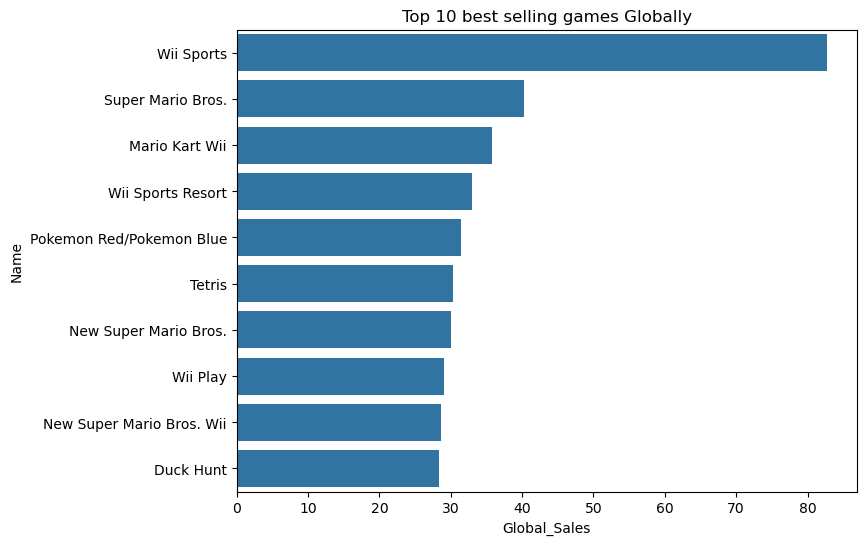

In [51]:
plt.figure(figsize = (8,6))
sns.barplot(x="Global_Sales", y="Name", data=top_games)
plt.title("Top 10 best selling games Globally")
plt.show()

In [52]:
# Which genre is most popular globally?
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending = False)
print(genre_sales)

Genre
Action          1751.18
Sports          1330.93
Shooter         1037.37
Role-Playing     927.37
Platform         831.37
Misc             809.96
Racing           732.04
Fighting         448.91
Simulation       391.91
Puzzle           244.95
Adventure        239.04
Strategy         175.12
Name: Global_Sales, dtype: float64


In [54]:
type(genre_sales)

pandas.core.series.Series

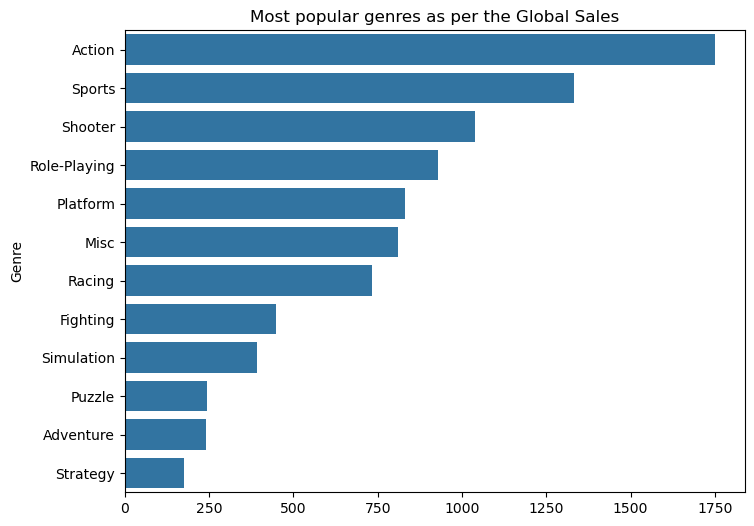

In [53]:
plt.figure(figsize = (8,6))
sns.barplot(x=genre_sales.values, y= genre_sales.index)
plt.title("Most popular genres as per the Global Sales")
plt.show()

In [55]:
# Which publisher has the highest Global sales?
publisher_sales = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False)
print(publisher_sales)

Publisher
Nintendo                       1786.56
Electronic Arts                1110.32
Activision                      727.46
Sony Computer Entertainment     607.50
Ubisoft                         474.43
                                ...   
Ongakukan                         0.01
Commseed                          0.01
Takuyo                            0.01
Boost On                          0.01
Naxat Soft                        0.01
Name: Global_Sales, Length: 578, dtype: float64


In [57]:
top_publisher_sales = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)
print(top_publisher_sales)

Publisher
Nintendo                        1786.56
Electronic Arts                 1110.32
Activision                       727.46
Sony Computer Entertainment      607.50
Ubisoft                          474.43
Take-Two Interactive             399.54
THQ                              340.77
Konami Digital Entertainment     283.64
Sega                             272.99
Namco Bandai Games               254.09
Name: Global_Sales, dtype: float64


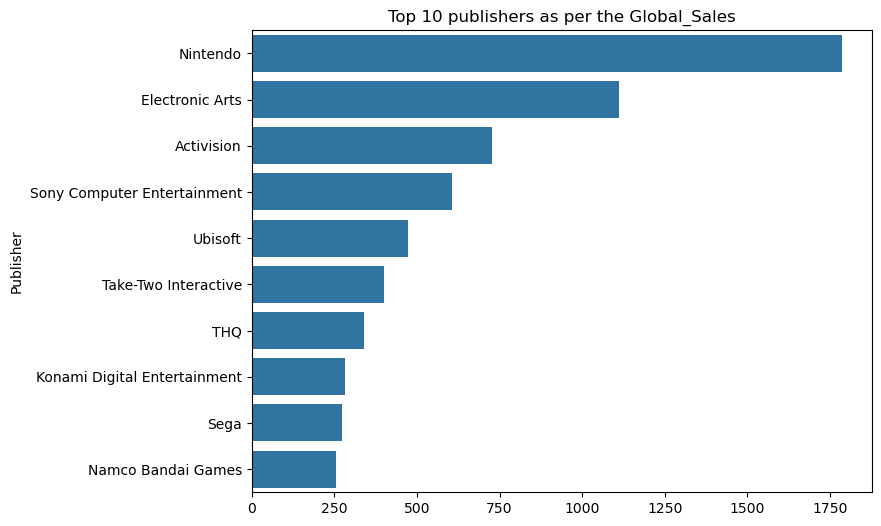

In [60]:
plt.figure(figsize = (8,6))
sns.barplot(x = top_publisher_sales.values, y=top_publisher_sales.index)
plt.title("Top 10 publishers as per the Global_Sales")
plt.show()

In [ ]:
Create a column by adding all the sales of you na,eu,jp and other sales and compare it with global sales
are the both columns having same values?

---
np.allclose(1.00034, 1.000367) -- True
- deep copy and shallow copy (view)-- flatten and ravel numpy

In [61]:
# Which region contributes most to global sales?
region_sales  = df[["NA_Sales","EU_Sales","JP_Sales","Other_Sales"]].sum()
print(region_sales)

NA_Sales       4392.68
EU_Sales       2434.13
JP_Sales       1291.02
Other_Sales     797.73
dtype: float64


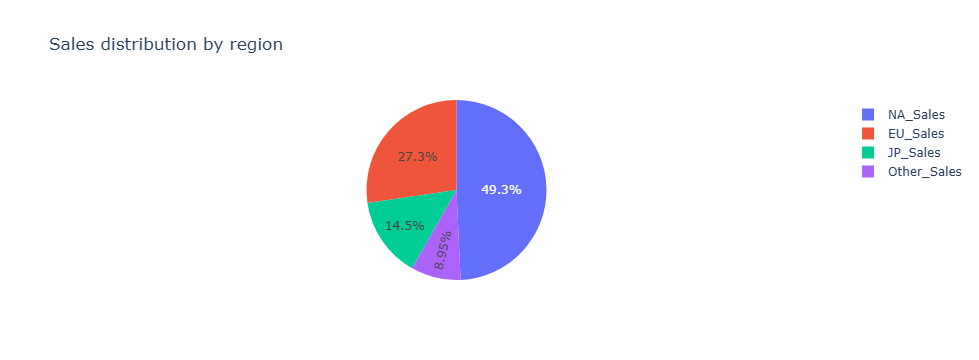

In [63]:
import plotly.express as px
fig = px.pie(values = region_sales.values, names =region_sales.index, title = "Sales distribution by region" )
fig.show()

In [ ]:
--> trend analysis -- line chart -- time(year)

In [ ]:
# Chart that shows the trend of global over the time period.

In [64]:
df1 = df[df['Year'] != 0]

In [65]:
yearly_sales = df1.groupby('Year')['Global_Sales'].sum().reset_index()
yearly_sales

,Year,Global_Sales
0,1980,11.38
1,1981,35.77
2,1982,28.86
3,1983,16.79
4,1984,50.36
5,1985,53.94
6,1986,37.07
7,1987,21.74
8,1988,47.22
9,1989,73.45


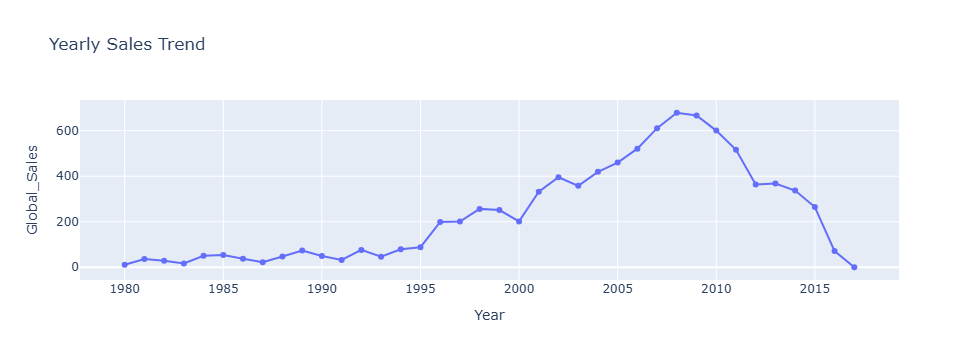

In [66]:
fig = px.line(
    yearly_sales,
    x = 'Year',
    y='Global_Sales',
    title = 'Yearly Sales Trend',
    markers = True
)

fig.show()